You are given an dataset containing customer transaction data from an e-commerce platform. Analyze the dataset using the **RFM (Recency, Frequency, Monetary)** approach to understand customer purchasing behavior. Based on the analysis, classify customers into predefined segments such as **Gold, Silver, Bronze, At Risk, and New** depending on their activity level, purchase frequency, and overall contribution to revenue. Derive meaningful insights from these segments to help the business understand which customers are most valuable, which are declining in engagement, and where to focus efforts for growth and retention.


In [30]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
!ls /content/drive/MyDrive/Datasets/Projects/2026/"RFM Analysis"

ecommerce_orders.csv


In [33]:
file_path= "/content/drive/MyDrive/Datasets/Projects/2026/RFM Analysis/ecommerce_orders.csv"
df_ecommerce_orders= pd.read_csv(file_path)
df_ecommerce_orders

,order_id,user_id,order_date,product,category,quantity,unit_price,payment_method,city
0,ORD000001,USR0127,2024-11-26 10:25,OnePlus Nord CE 3,Electronics,1,21910,Credit Card,Vadodara
1,ORD000002,USR0005,2024-08-18 12:52,Realme Buds Wireless,Electronics,1,1560,Credit Card,Varanasi
2,ORD000003,USR0006,2024-10-19 18:25,Bedsheet King Size,Home & Kitchen,4,1209,Credit Card,Chennai
3,ORD000004,USR0046,2024-07-26 05:20,Stainless Steel Casserole,Home & Kitchen,2,1929,UPI,Vadodara
4,ORD000005,USR0078,2024-11-19 03:47,NCERT Class 12 Physics,Books & Stationery,4,310,Cash on Delivery,Lucknow
...,...,...,...,...,...,...,...,...,...
995,ORD000996,USR0062,2024-12-08 23:21,Wall Clock Wooden,Home & Kitchen,1,1840,UPI,Nashik
996,ORD000997,USR0035,2024-06-13 10:55,Sticky Notes Multicolor Pack,Books & Stationery,3,180,Credit Card,Chennai
997,ORD000998,USR0013,2024-12-11 05:14,Ethnic Saree,Fashion,2,2360,Credit Card,Thane
998,ORD000999,USR0095,2024-06-04 19:45,The Moms Co. Baby Wash,Beauty & Personal Care,4,419,EMI,Surat


In [34]:
df_ecommerce_orders.shape

(1000, 9)

In [35]:
df_ecommerce_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        1000 non-null   object
 1   user_id         1000 non-null   object
 2   order_date      1000 non-null   object
 3   product         1000 non-null   object
 4   category        1000 non-null   object
 5   quantity        1000 non-null   int64 
 6   unit_price      1000 non-null   int64 
 7   payment_method  1000 non-null   object
 8   city            1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [36]:
df_ecommerce_orders.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,1000.0,2.013,1.219967,1.0,1.0,2.0,3.0,5.0
unit_price,1000.0,1630.858,3319.774605,99.0,420.0,749.5,1479.0,24959.0


In [37]:
df_ecommerce_orders.describe(exclude=np.number).T

,count,unique,top,freq
order_id,1000,1000,ORD001000,1
user_id,1000,249,USR0014,19
order_date,1000,998,2024-10-02 18:35,2
product,1000,68,Sticky Notes Multicolor Pack,27
category,1000,7,Beauty & Personal Care,153
payment_method,1000,5,UPI,383
city,1000,54,Agra,87


In [38]:
df_ecommerce_orders["order_date"]=pd.to_datetime(df_ecommerce_orders["order_date"])

In [39]:
df_ecommerce_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1000 non-null   object        
 1   user_id         1000 non-null   object        
 2   order_date      1000 non-null   datetime64[ns]
 3   product         1000 non-null   object        
 4   category        1000 non-null   object        
 5   quantity        1000 non-null   int64         
 6   unit_price      1000 non-null   int64         
 7   payment_method  1000 non-null   object        
 8   city            1000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


In [40]:
df_ecommerce_orders["order_date"].max().normalize()

Timestamp('2025-03-15 00:00:00')

Since the dataset is historical, we don’t use today’s real date rather simulate a “current date” like this:

In [41]:
#For Monetory we need revenue
df_ecommerce_orders["revenue"]= df_ecommerce_orders["unit_price"]*df_ecommerce_orders["quantity"]
df_ecommerce_orders

,order_id,user_id,order_date,product,category,quantity,unit_price,payment_method,city,revenue
0,ORD000001,USR0127,2024-11-26 10:25:00,OnePlus Nord CE 3,Electronics,1,21910,Credit Card,Vadodara,21910
1,ORD000002,USR0005,2024-08-18 12:52:00,Realme Buds Wireless,Electronics,1,1560,Credit Card,Varanasi,1560
2,ORD000003,USR0006,2024-10-19 18:25:00,Bedsheet King Size,Home & Kitchen,4,1209,Credit Card,Chennai,4836
3,ORD000004,USR0046,2024-07-26 05:20:00,Stainless Steel Casserole,Home & Kitchen,2,1929,UPI,Vadodara,3858
4,ORD000005,USR0078,2024-11-19 03:47:00,NCERT Class 12 Physics,Books & Stationery,4,310,Cash on Delivery,Lucknow,1240
...,...,...,...,...,...,...,...,...,...,...
995,ORD000996,USR0062,2024-12-08 23:21:00,Wall Clock Wooden,Home & Kitchen,1,1840,UPI,Nashik,1840
996,ORD000997,USR0035,2024-06-13 10:55:00,Sticky Notes Multicolor Pack,Books & Stationery,3,180,Credit Card,Chennai,540
997,ORD000998,USR0013,2024-12-11 05:14:00,Ethnic Saree,Fashion,2,2360,Credit Card,Thane,4720
998,ORD000999,USR0095,2024-06-04 19:45:00,The Moms Co. Baby Wash,Beauty & Personal Care,4,419,EMI,Surat,1676


In [42]:
df_ecommerce_orders["order_date"].max().normalize() + pd.Timedelta(days=1)

Timestamp('2025-03-16 00:00:00')

In [43]:
reference_date = df_ecommerce_orders["order_date"].max()+ pd.Timedelta(days=1)
reference_date

Timestamp('2025-03-16 22:54:00')

In [44]:
df_ecommerce_orders["order_date"].dt.normalize()

,order_date
0,2024-11-26
1,2024-08-18
2,2024-10-19
3,2024-07-26
4,2024-11-19
...,...
995,2024-12-08
996,2024-06-13
997,2024-12-11
998,2024-06-04


In [45]:
# (reference_date - x.max().normalize()).days
# returns the difference in days, but the result may still include leftover hours internally

# round((reference_date - x.max()).total_seconds() / 86400)
# converts the full time difference into days and rounds it to the nearest whole number

In [46]:
rfm=df_ecommerce_orders.groupby("user_id").agg(recency=("order_date",
                                                        lambda x: round((reference_date - x.max()).total_seconds() / 86400))    ,
                                                frequency=("order_id","count"),  monetory=("revenue","sum")  )
rfm

,recency,frequency,monetory
user_id,,,
USR0001,45,18,35980
USR0002,4,19,58939
USR0003,12,15,27886
USR0004,3,17,51864
USR0005,29,14,23756
...,...,...,...
USR0246,254,1,719
USR0247,313,1,509
USR0248,214,2,3169


In [47]:
rfm= rfm.reset_index()
rfm

,user_id,recency,frequency,monetory
0,USR0001,45,18,35980
1,USR0002,4,19,58939
2,USR0003,12,15,27886
3,USR0004,3,17,51864
4,USR0005,29,14,23756
...,...,...,...,...
244,USR0246,254,1,719
245,USR0247,313,1,509
246,USR0248,214,2,3169
247,USR0249,223,1,600


When I use pd.qcut(column, 5, labels=[...]), I am dividing the data into 5 equal groups (quantiles) based on the distribution of values. The data is automatically sorted in the backend, and each group contains approximately the same number of observations.

If I give labels like **[1, 2, 3, 4, 5]**, then:

- The lowest values fall into the first group and get label 1

- The next group gets label 2

- This continues until the highest values get label 5

So the labels are assigned in increasing order of the values.

For Recency, lower values are better because a smaller number of days means the customer purchased recently. So I reverse the labels to reflect this business logic to **[5,4,3,2,1]**

**Note: Always think how to give scoring based on the business logic**

In [48]:
rfm["rscore"]=pd.qcut(rfm["recency"],5,labels=[5,4,3,2,1])   #low is good
rfm["rscore"]

,rscore
0,4
1,5
2,5
3,5
4,4
...,...
244,1
245,1
246,2
247,2


**Error - Extra **  
- rfm["fscore"]=pd.qcut(rfm["frequency"],5,labels=[1, 2, 3, 4, 5]) #low is good

For the frequency column, I faced an issue while using pd.qcut because many users had the same purchase count, like 1 or 2, creating a high concentration of similar values. Because of this, when trying to split the data into 5 equal groups, multiple groups ended at the same value, which resulted in duplicate boundaries and caused the error “bin edges must be unique”. To handle this, I used ranking before applying qcut, which converts the frequency values into a unique ordered sequence while preserving their relative position. This ensures that each group can be clearly separated and all 5 quantiles are formed properly. An alternative approach could have been using the duplicates parameter to drop duplicate bins, but that would reduce the number of groups and make the segmentation less consistent, so ranking is a better approach here.

In [49]:
rfm["fscore"]=pd.qcut(rfm["frequency"].rank(method="first"),5,labels=[1, 2, 3, 4, 5]) #low is good
rfm["fscore"]

,fscore
0,5
1,5
2,5
3,5
4,5
...,...
244,2
245,2
246,3
247,2


In [50]:
rfm["mscore"]=pd.qcut(rfm["monetory"],5,labels=[1, 2, 3, 4, 5]) #high is good
rfm["mscore"]

,mscore
0,5
1,5
2,5
3,5
4,5
...,...
244,1
245,1
246,2
247,1


In [51]:
rfm

,user_id,recency,frequency,monetory,rscore,fscore,mscore
0,USR0001,45,18,35980,4,5,5
1,USR0002,4,19,58939,5,5,5
2,USR0003,12,15,27886,5,5,5
3,USR0004,3,17,51864,5,5,5
4,USR0005,29,14,23756,4,5,5
...,...,...,...,...,...,...,...
244,USR0246,254,1,719,1,2,1
245,USR0247,313,1,509,1,2,1
246,USR0248,214,2,3169,2,3,2
247,USR0249,223,1,600,2,2,1


In [52]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   user_id    249 non-null    object  
 1   recency    249 non-null    int64   
 2   frequency  249 non-null    int64   
 3   monetory   249 non-null    int64   
 4   rscore     249 non-null    category
 5   fscore     249 non-null    category
 6   mscore     249 non-null    category
dtypes: category(3), int64(3), object(1)
memory usage: 9.3+ KB


In [53]:
rfm["rscore"]=pd.to_numeric(rfm["rscore"])
rfm["fscore"]=pd.to_numeric(rfm["fscore"])
rfm["mscore"]=pd.to_numeric(rfm["mscore"])

In [54]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    249 non-null    object
 1   recency    249 non-null    int64 
 2   frequency  249 non-null    int64 
 3   monetory   249 non-null    int64 
 4   rscore     249 non-null    int64 
 5   fscore     249 non-null    int64 
 6   mscore     249 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 13.7+ KB



- Gold → high R, high F, high M

- New → high R, low F, low M

- At-Risk → low R, high F, high M

- Silver → medium to high everything

- Bronze → everything else

#### Eg Recency

| Score | Meaning     |
| ----- | ----------- |
| 5     | very recent |
| 4     | recent      |
| 3     | okay        |
| 2     | old         |
| 1     | very old    |


In [55]:
def segment(row):
    r = int(row["rscore"])
    f = int(row["fscore"])
    m = int(row["mscore"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Gold"

    elif r == 5 and f <= 2 and m <= 2:
        return "New"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At-Risk"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Silver"

    else:
        return "Bronze"

In [56]:
rfm["segment"] = rfm.apply(segment,axis=1)

In [57]:
rfm

,user_id,recency,frequency,monetory,rscore,fscore,mscore,segment
0,USR0001,45,18,35980,4,5,5,Gold
1,USR0002,4,19,58939,5,5,5,Gold
2,USR0003,12,15,27886,5,5,5,Gold
3,USR0004,3,17,51864,5,5,5,Gold
4,USR0005,29,14,23756,4,5,5,Gold
...,...,...,...,...,...,...,...,...
244,USR0246,254,1,719,1,2,1,Bronze
245,USR0247,313,1,509,1,2,1,Bronze
246,USR0248,214,2,3169,2,3,2,Bronze
247,USR0249,223,1,600,2,2,1,Bronze


**exta - not required**
- seg= rfm.segment.value_counts()
- seg = category.to_frame(name="count")

In [58]:

category_count=rfm.groupby("segment").size().to_frame("count")
category_count["percentage"]=(rfm["segment"].value_counts(normalize=True)*100).round()
category_count

,count,percentage
segment,,
At-Risk,20,8.0
Bronze,123,49.0
Gold,54,22.0
New,5,2.0
Silver,47,19.0


In [59]:
category_count=category_count.reset_index()
category_count

,segment,count,percentage
0,At-Risk,20,8.0
1,Bronze,123,49.0
2,Gold,54,22.0
3,New,5,2.0
4,Silver,47,19.0


Most customers fall under Bronze, which indicates low frequency or low spending behavior, so there is a large opportunity to improve engagement. The Gold segment is reasonably strong, contributing high value, and should be retained through loyalty or rewards programs. Silver customers form a good mid-tier group that can be targeted with upsell or cross-sell strategies to move them into Gold. The At-Risk segment, although smaller, represents users who were previously valuable but are no longer active, so re-engagement campaigns are important here. The New segment is quite low, suggesting that customer acquisition or onboarding efforts may need improvement.

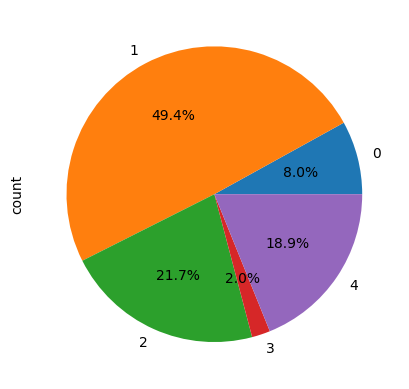

In [60]:
category_count["count"].plot(kind="pie", autopct="%1.1f%%");